# Chronic Kidney Disease Classification Using Machine Learning

## Problem Statement

Develop a machine learning model to classify whether Chronic Kidney Disease (CKD) is present or not based on patient clinical attributes.

## Objective

To build and evaluate machine learning models for the prediction of Chronic Kidney Disease using patient medical records.

## Dataset Information

The Chronic Kidney Disease dataset contains 400 patient records and 25 clinical attributes. The objective is to classify whether a patient has Chronic Kidney Disease (CKD) or not based on medical parameters such as blood pressure, albumin, sugar level, hemoglobin, serum creatinine and other health indicators.

# 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Loading the Dataset

In [2]:
df = pd.read_csv("kidney_disease.csv")

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


# 3. Understanding the Dataset

This section explores the dataset structure, dimensions, data types and statistical properties.

In [3]:
df.shape

(400, 26)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                70
wc                105
rc                130
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

In [6]:
df.describe()

,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [7]:
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

# 4. Data Cleaning and Preprocessing

The dataset contains missing values and inconsistent data types. These issues are handled before model training.

In [8]:
df.drop('id', axis=1, inplace=True)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [9]:
df['pcv'] = pd.to_numeric(df['pcv'], errors='coerce')
df['wc'] = pd.to_numeric(df['wc'], errors='coerce')
df['rc'] = pd.to_numeric(df['rc'], errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [11]:
# Remove leading/trailing spaces and tabs from all object columns

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

In [12]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [14]:
df.isnull().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

# 5. Exploratory Data Analysis (EDA)

Visual analysis is performed to understand class distribution and feature relationships.

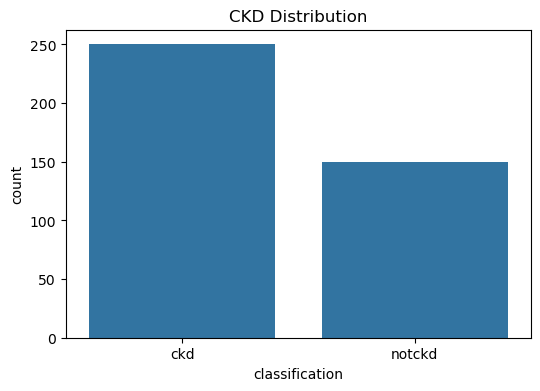

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='classification', data=df)

plt.title('CKD Distribution')
plt.show()

In [16]:
df['classification'].unique()

array(['ckd', 'notckd'], dtype=object)

In [17]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')

# 6. Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore categorical features are converted into numerical form using Label Encoding.

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [19]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.0,...,44.0,7800.0,5.2,2,2,1,0,1,1,0
1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,121.0,...,38.0,6000.0,4.8,1,1,1,0,1,1,0
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,423.0,...,31.0,7500.0,4.8,1,2,1,2,1,2,0
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.0,...,32.0,6700.0,3.9,2,1,1,2,2,2,0
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.0,...,35.0,7300.0,4.6,1,1,1,0,1,1,0


# 7. Correlation Analysis

A correlation heatmap is used to understand relationships between different features and the target variable.

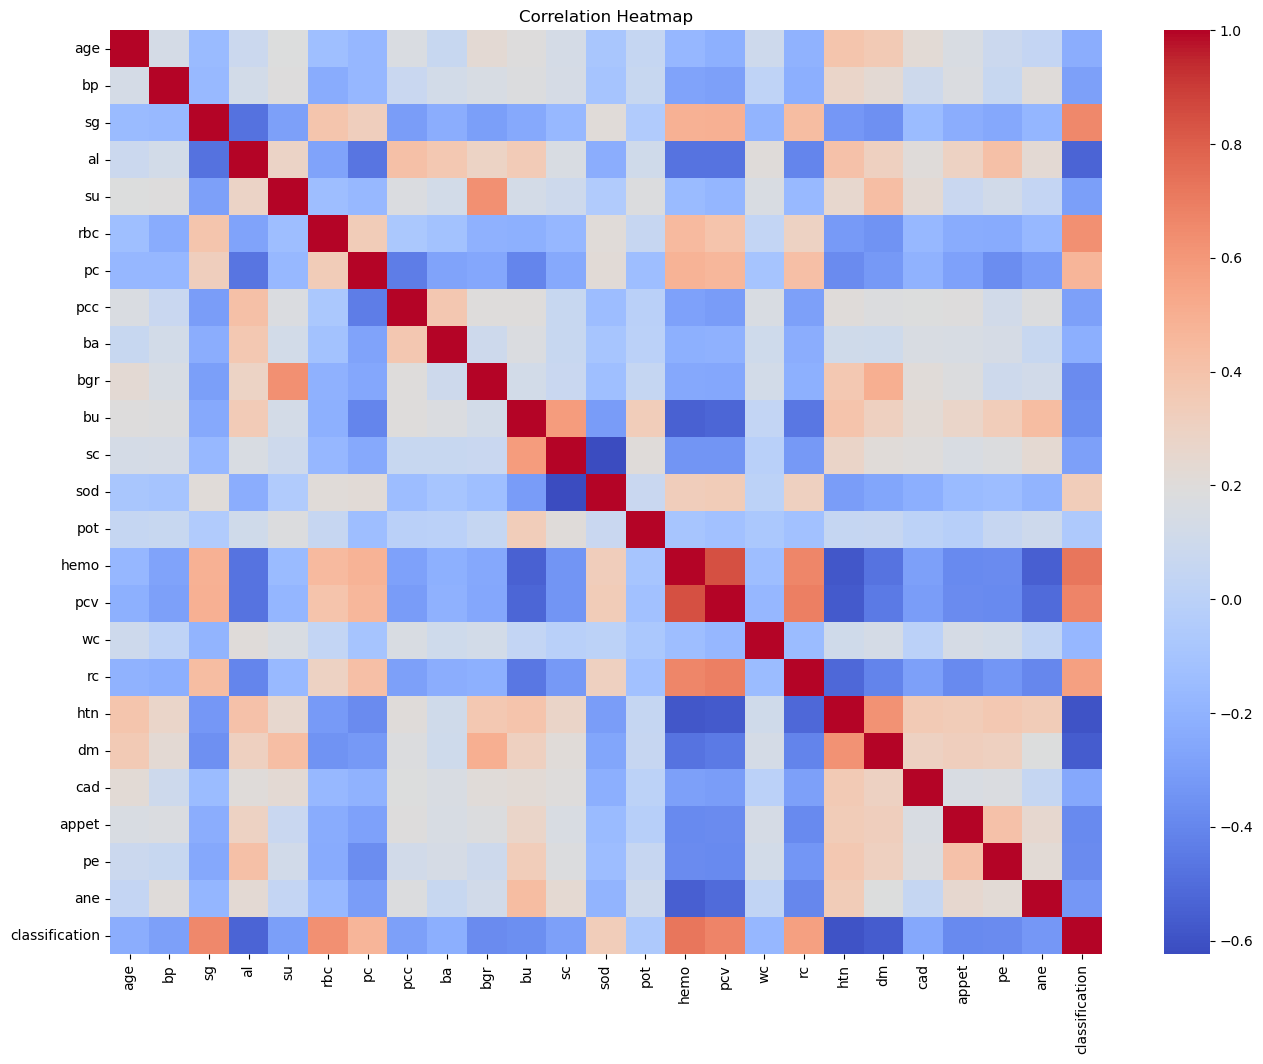

In [20]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# 8. Feature Selection and Train-Test Split

The dataset is divided into input features (X) and target variable (y), followed by splitting into training and testing datasets.

In [21]:
X = df.drop('classification', axis=1)

y = df['classification']

In [22]:
print(X.shape)
print(y.shape)

(400, 24)
(400,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
print(X_train.shape)
print(X_test.shape)

(320, 24)
(80, 24)


# 9. Model Training and Evaluation

Three machine learning algorithms are trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Evaluation metrics include Accuracy, Precision, Recall, F1 Score, Specificity and Confusion Matrix.

In [25]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print("Accuracy    :", round(accuracy, 4))
    print("Precision   :", round(precision, 4))
    print("Recall      :", round(recall, 4))
    print("F1 Score    :", round(f1, 4))
    print("Specificity :", round(specificity, 4))

    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 9.1 Logistic Regression

C:\Users\Kalash Agrawal\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy    : 1.0
Precision   : 1.0
Recall      : 1.0
F1 Score    : 1.0
Specificity : 1.0

Confusion Matrix:
[[52  0]
 [ 0 28]]


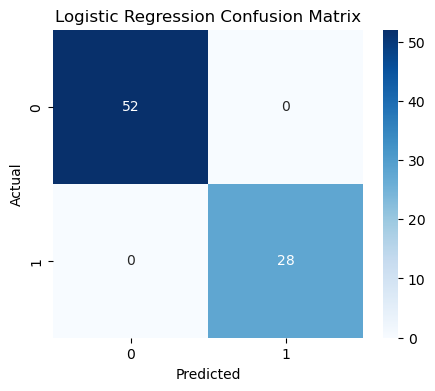

In [26]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

## 9.2 Decision Tree Classifier


Decision Tree
Accuracy    : 1.0
Precision   : 1.0
Recall      : 1.0
F1 Score    : 1.0
Specificity : 1.0

Confusion Matrix:
[[52  0]
 [ 0 28]]


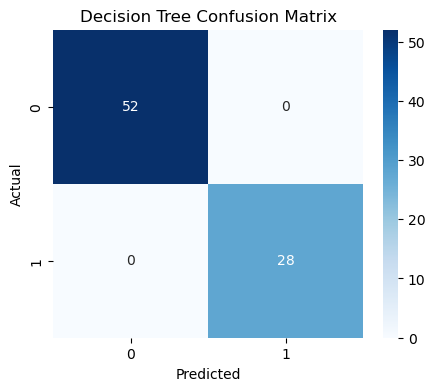

In [27]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

## 9.3 Random Forest Classifier


Random Forest
Accuracy    : 1.0
Precision   : 1.0
Recall      : 1.0
F1 Score    : 1.0
Specificity : 1.0

Confusion Matrix:
[[52  0]
 [ 0 28]]


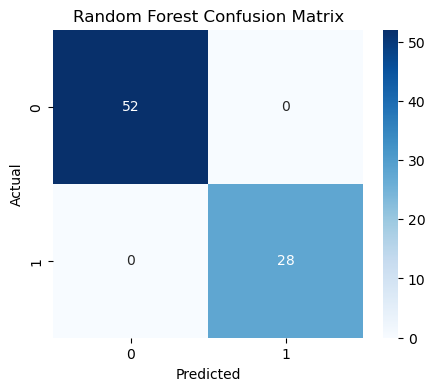

In [28]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

# 10. Feature Importance Analysis

Random Forest provides feature importance scores which indicate the contribution of each feature towards CKD prediction.

In [29]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

importance.head(10)

pcv     0.157226
sc      0.147161
hemo    0.145669
sg      0.094424
rc      0.092951
rbc     0.084815
al      0.076708
dm      0.053706
sod     0.027290
bgr     0.024082
dtype: float64

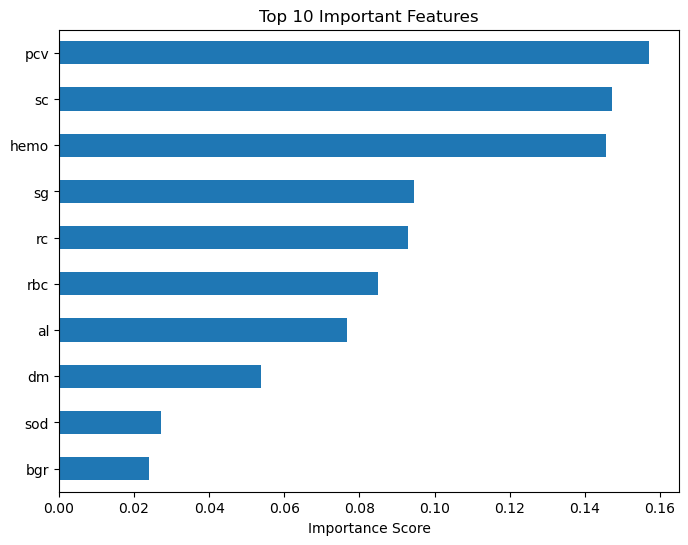

In [30]:
plt.figure(figsize=(8,6))

importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

# 11. Model Saving

In [31]:
import pickle

best_model = rf

pickle.dump(
    best_model,
    open("ckd_model.pkl", "wb")
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


# 12. Conclusion

In this project, machine learning techniques were applied to classify Chronic Kidney Disease using patient clinical data.

Three models were developed:

- Logistic Regression
- Decision Tree
- Random Forest

Among the three models, Random Forest achieved the highest performance with 100% accuracy on the test dataset and was selected as the final prediction model.

The developed system can assist in the early identification of Chronic Kidney Disease and support healthcare decision-making.